# One sample analysis

## 🧬 Overview
### In this analysis, I’ve used one of the Squidpy demo samples, so you can easily grab the same one and give it a try yourself! 🧠✨

In [15]:
import os

notebookPath = os.path.dirname(os.getcwd())

In [2]:
import os
import numpy as np
import scanpy as sc
import pandas as pd
import spatools as st
import matplotlib as mpl
import matplotlib.pyplot as plt

In [16]:
import squidpy as sq
sq.datasets.visium_hne_adata(os.path.join(notebookPath, "singleSpatial", "adata.h5ad"))

100%|██████████| 314M/314M [00:30<00:00, 10.8MB/s] 


AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [23]:
import anndata as an
adata = an.read_h5ad(os.path.join(notebookPath, "singleSpatial", "adata.h5ad"))

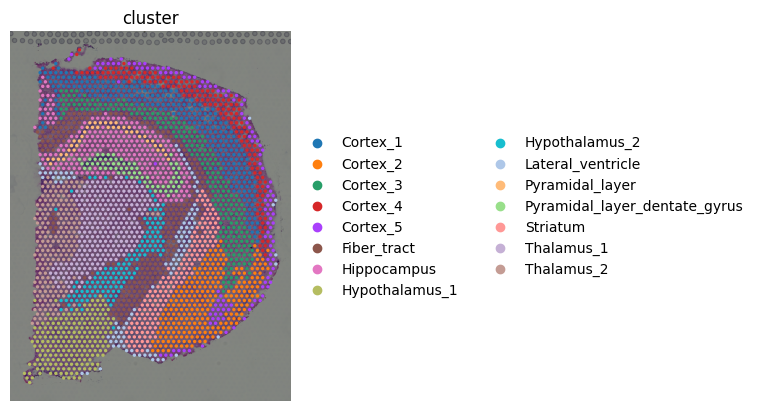

In [24]:
import matplotlib.pyplot as plt

sc.pl.spatial(adata, color="cluster", frameon=False)# type: ignore

In [25]:
adata.obs["cluster"]

AAACAAGTATCTCCCA-1             Cortex_2
AAACAATCTACTAGCA-1             Cortex_5
AAACACCAATAACTGC-1           Thalamus_2
AAACAGAGCGACTCCT-1             Cortex_5
AAACCGGGTAGGTACC-1           Thalamus_2
                            ...        
TTGTTGTGTGTCAAGA-1    Lateral_ventricle
TTGTTTCACATCCAGG-1       Hypothalamus_1
TTGTTTCATTAGTCTA-1       Hypothalamus_1
TTGTTTCCATACAACT-1           Thalamus_2
TTGTTTGTGTAAATTC-1             Cortex_4
Name: cluster, Length: 2688, dtype: category
Categories (15, object): ['Cortex_1', 'Cortex_2', 'Cortex_3', 'Cortex_4', ..., 'Pyramidal_layer_dentate_gyrus', 'Striatum', 'Thalamus_1', 'Thalamus_2']

In [26]:
adata = st.tl.correlate_distances(adata, is_concatenated=False, cluster_col="cluster")

In [27]:
type(adata.obsm["spatial"])

numpy.ndarray

In [28]:
adata.obsm["spatial"]

array([[8230, 7237],
       [4170, 1611],
       [2519, 8315],
       ...,
       [3276, 8435],
       [3069, 6639],
       [4720, 2090]])

In [29]:
adata.uns["spatools"]

,x,y,point_name,color,x_neigh,y_neigh,color_neigh,distance,combination
0,8230,7237,8230_7237,Cortex_2,8367,7237,Cortex_5,137.000000,"(Cortex_2, Cortex_5)"
1,8230,7237,8230_7237,Cortex_2,8161,7357,Cortex_2,138.423264,"(Cortex_2, Cortex_2)"
2,8230,7237,8230_7237,Cortex_2,8092,7237,Cortex_2,138.000000,"(Cortex_2, Cortex_2)"
3,8230,7237,8230_7237,Cortex_2,8298,7357,Cortex_5,137.927517,"(Cortex_2, Cortex_5)"
4,8230,7237,8230_7237,Cortex_2,8161,7118,Cortex_2,137.557261,"(Cortex_2, Cortex_2)"
...,...,...,...,...,...,...,...,...,...
15575,4720,2090,4720_2090,Cortex_4,4858,2090,Cortex_1,138.000000,"(Cortex_1, Cortex_4)"
15576,4720,2090,4720_2090,Cortex_4,4651,2209,Cortex_1,137.557261,"(Cortex_1, Cortex_4)"
15577,4720,2090,4720_2090,Cortex_4,4789,1970,Cortex_4,138.423264,"(Cortex_4, Cortex_4)"
15578,4720,2090,4720_2090,Cortex_4,4651,1970,Cortex_4,138.423264,"(Cortex_4, Cortex_4)"


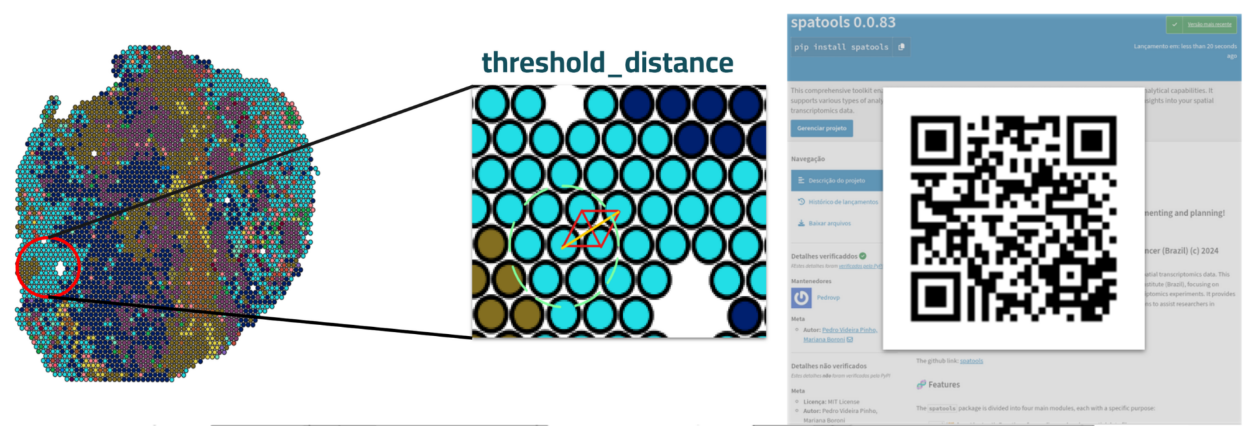

In [32]:
import imageio.v3 as iio
import matplotlib.pyplot as plt

img = iio.imread(os.path.join(notebookPath, "imgs", "spatoolsDist.png"))

plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [33]:
adata = st.tl.z_score(adata)

/home/pedrovp/anaconda3/envs/scviInt/lib/python3.9/site-packages/spatools/tools/tl.py:611: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z_matrix.fillna(0, inplace=True)


In [34]:
adata.uns["zscore_matrix"]["sample"]

,Cortex_1,Cortex_2,Cortex_3,Cortex_4,Cortex_5,Fiber_tract,Hippocampus,Hypothalamus_1,Hypothalamus_2,Lateral_ventricle,Pyramidal_layer,Pyramidal_layer_dentate_gyrus,Striatum,Thalamus_1,Thalamus_2
Cortex_1,0.000000,-6.001364,31.667341,30.016554,-5.576356,-8.200633,0.706459,-3.886326,-6.705850,-6.679076,-4.820076,-4.708580,-5.619295,-5.697919,-5.650871
Cortex_2,-6.001364,0.000000,15.280089,-2.757309,25.329224,-7.597942,-7.257411,-3.253869,-5.607779,-3.057729,-4.034336,-3.941184,18.834638,-4.767300,-4.728038
Cortex_3,31.667341,15.280089,0.000000,-6.962526,-6.127932,9.725591,-7.924944,-3.862013,-6.663564,-6.636962,-4.789856,-4.679067,0.917617,-5.662108,-5.615361
Cortex_4,30.016554,-2.757309,-6.962526,0.000000,38.816777,-8.426579,-8.047658,-3.603518,-6.214347,-6.189577,-4.468630,-4.365351,-5.208752,-5.281543,-5.237986
Cortex_5,-5.576356,25.329224,-6.127932,38.816777,0.000000,-8.143092,-6.209056,-3.484070,-6.006999,0.767455,-4.320240,-4.220425,-5.035467,-5.105801,-5.063715
Fiber_tract,-8.200633,-7.597942,9.725591,-8.426579,-8.143092,0.000000,7.636525,-1.645142,14.656462,13.256713,-5.439155,-5.653609,6.145835,3.509804,0.369816
Hippocampus,0.706459,-7.257411,-7.924944,-8.047658,-6.209056,7.636525,0.000000,-4.457188,-4.269990,1.337737,41.147292,33.408617,-6.449247,-5.611606,-6.485585
Hypothalamus_1,-3.886326,-3.253869,-3.862013,-3.603518,-3.484070,-1.645142,-4.457188,0.000000,14.578076,7.656675,-2.485268,-2.428035,-2.894960,-2.935207,17.058302
Hypothalamus_2,-6.705850,-5.607779,-6.663564,-6.214347,-6.006999,14.656462,-4.269990,14.578076,0.000000,-3.538881,-4.278127,0.628905,-4.986294,20.436627,10.647590
Lateral_ventricle,-6.679076,-3.057729,-6.636962,-6.189577,0.767455,13.256713,1.337737,7.656675,-3.538881,0.000000,-4.261167,-4.162730,20.573484,-4.635962,1.859467


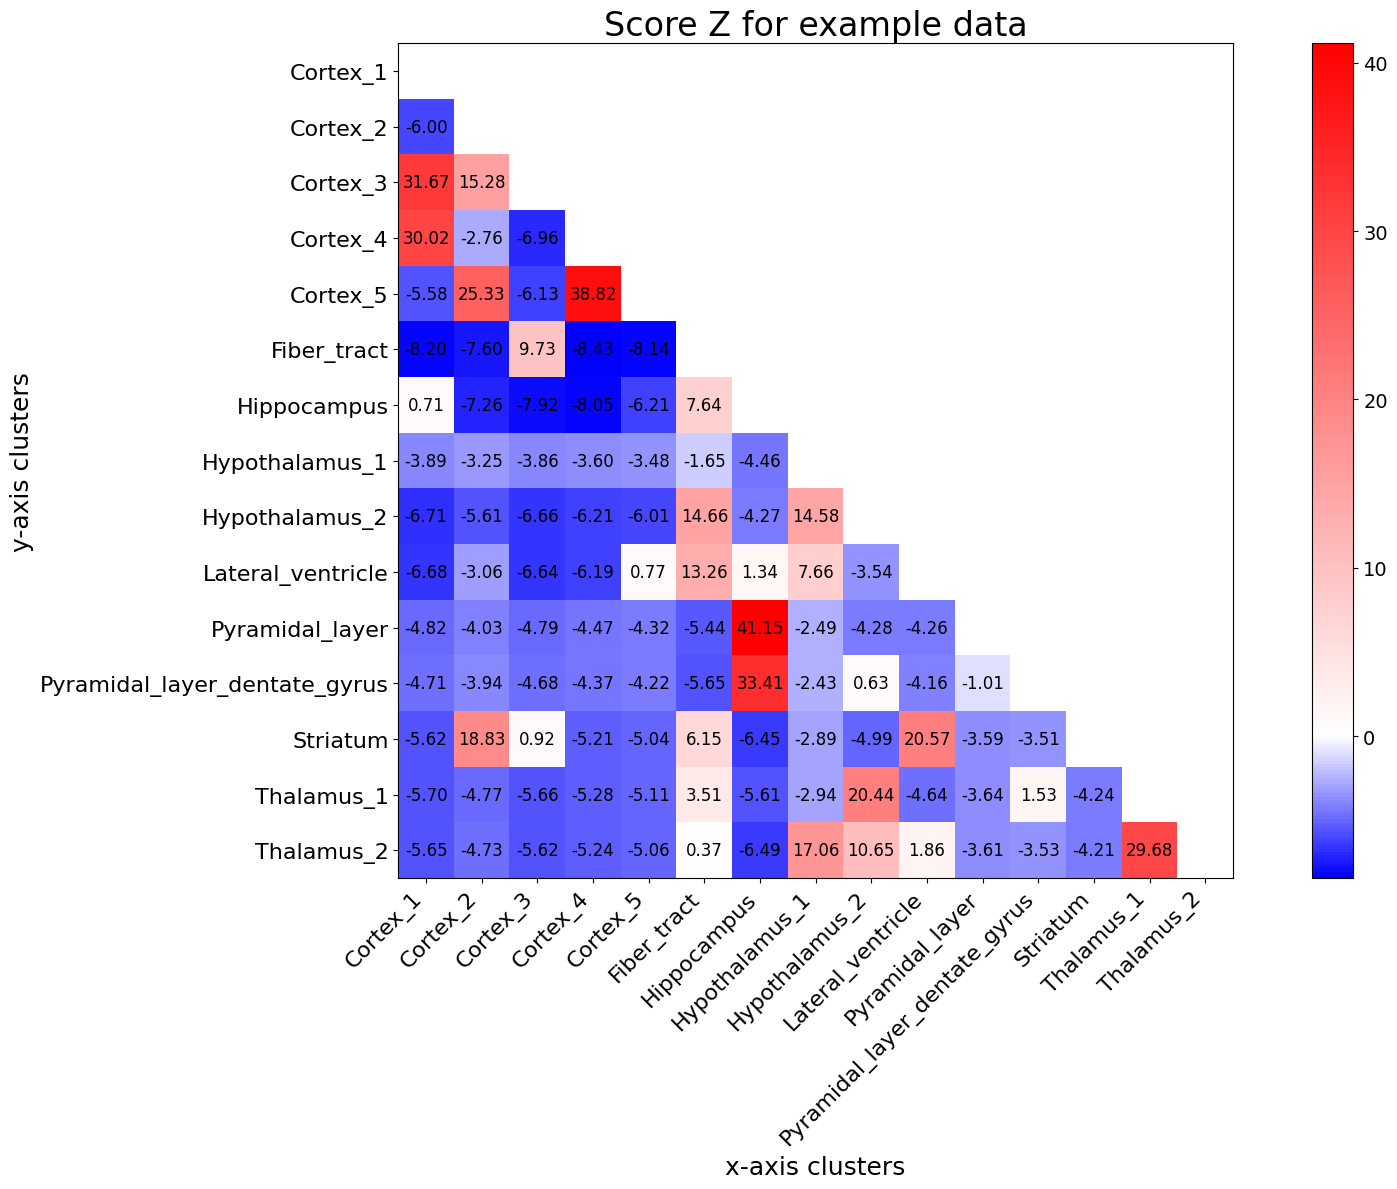

,Cortex_1,Cortex_2,Cortex_3,Cortex_4,Cortex_5,Fiber_tract,Hippocampus,Hypothalamus_1,Hypothalamus_2,Lateral_ventricle,Pyramidal_layer,Pyramidal_layer_dentate_gyrus,Striatum,Thalamus_1,Thalamus_2
Cortex_1,0.000000,-6.001364,31.667341,30.016554,-5.576356,-8.200633,0.706459,-3.886326,-6.705850,-6.679076,-4.820076,-4.708580,-5.619295,-5.697919,-5.650871
Cortex_2,-6.001364,0.000000,15.280089,-2.757309,25.329224,-7.597942,-7.257411,-3.253869,-5.607779,-3.057729,-4.034336,-3.941184,18.834638,-4.767300,-4.728038
Cortex_3,31.667341,15.280089,0.000000,-6.962526,-6.127932,9.725591,-7.924944,-3.862013,-6.663564,-6.636962,-4.789856,-4.679067,0.917617,-5.662108,-5.615361
Cortex_4,30.016554,-2.757309,-6.962526,0.000000,38.816777,-8.426579,-8.047658,-3.603518,-6.214347,-6.189577,-4.468630,-4.365351,-5.208752,-5.281543,-5.237986
Cortex_5,-5.576356,25.329224,-6.127932,38.816777,0.000000,-8.143092,-6.209056,-3.484070,-6.006999,0.767455,-4.320240,-4.220425,-5.035467,-5.105801,-5.063715
Fiber_tract,-8.200633,-7.597942,9.725591,-8.426579,-8.143092,0.000000,7.636525,-1.645142,14.656462,13.256713,-5.439155,-5.653609,6.145835,3.509804,0.369816
Hippocampus,0.706459,-7.257411,-7.924944,-8.047658,-6.209056,7.636525,0.000000,-4.457188,-4.269990,1.337737,41.147292,33.408617,-6.449247,-5.611606,-6.485585
Hypothalamus_1,-3.886326,-3.253869,-3.862013,-3.603518,-3.484070,-1.645142,-4.457188,0.000000,14.578076,7.656675,-2.485268,-2.428035,-2.894960,-2.935207,17.058302
Hypothalamus_2,-6.705850,-5.607779,-6.663564,-6.214347,-6.006999,14.656462,-4.269990,14.578076,0.000000,-3.538881,-4.278127,0.628905,-4.986294,20.436627,10.647590
Lateral_ventricle,-6.679076,-3.057729,-6.636962,-6.189577,0.767455,13.256713,1.337737,7.656675,-3.538881,0.000000,-4.261167,-4.162730,20.573484,-4.635962,1.859467


In [35]:
import spatools as st
st.pl.z_score_matrixplot(adata, show=True, title="Score Z for example data", return_object=True)

In [36]:
adata.uns["z-score"]["sample"]

,combination,count,proportion_observed,proportion_expected,std_dev,Z_score
0,"(Cortex_1, Cortex_2)",2.0,0.000543,0.010736,0.001698,-6.001364
1,"(Cortex_1, Cortex_3)",290.0,0.078762,0.015106,0.002010,31.667341
2,"(Cortex_1, Cortex_4)",256.0,0.069527,0.013158,0.001878,30.016554
3,"(Cortex_1, Cortex_5)",8.0,0.002173,0.012303,0.001817,-5.576356
4,"(Cortex_1, Fiber_tract)",8.0,0.002173,0.021994,0.002417,-8.200633
...,...,...,...,...,...,...
100,"(Pyramidal_layer_dentate_gyrus, Thalamus_1)",18.0,0.004889,0.003420,0.000962,1.526232
101,"(Pyramidal_layer_dentate_gyrus, Thalamus_2)",0.0,0.000000,0.003364,0.000954,-3.525571
102,"(Striatum, Thalamus_1)",0.0,0.000000,0.004859,0.001146,-4.240003
103,"(Striatum, Thalamus_2)",0.0,0.000000,0.004780,0.001137,-4.205129


In [37]:
adata.uns["check_spots"]

,spots_analysed,total_spots_anndata,percentage
Sample,2688,2688,100.0


# Multi-sample analysis

## 🧬 Overview
### In this analysis I've used a sample from my project in which there are good, bad and partial responders.
## ⚠️ Note:
### The following steps should be repeated for all three categories.

In [51]:
import os

notebookPath = os.path.dirname(os.getcwd())

In [52]:
import os
import numpy as np
import scanpy as sc
import pandas as pd
import spatools as st 
import matplotlib as mpl
import matplotlib.pyplot as plt

adata = sc.read(os.path.join(notebookPath, "outputIntegrated", "output.scviAnndataTrained.h5ad"))

adata = st.tl.correlate_distances(adata, is_concatenated=True, cluster_col="leiden_0.5", batch_key="library_id")

In [53]:
type(adata.obsm["spatial"])# spatial data must be like this

numpy.ndarray

In [54]:
adata.obsm["spatial"]# spatial data must be like this

array([[4126., 1601.],
       [3144., 6006.],
       [4051., 7137.],
       ...,
       [1110., 2105.],
       [ 890., 2168.],
       [1091., 2583.]])

In [55]:
adata.uns["spatools"]# output of the previous function

,x,y,point_name,color,x_neigh,y_neigh,color_neigh,distance,library_id,combination
0,4126.0,1601.0,4126.0_1601.0,0,4256.0,1601.0,0,130.000000,FB_P1_S2,"(0, 0)"
1,4126.0,1601.0,4126.0_1601.0,0,4061.0,1488.0,0,130.361037,FB_P1_S2,"(0, 0)"
2,4126.0,1601.0,4126.0_1601.0,0,4061.0,1714.0,0,130.361037,FB_P1_S2,"(0, 0)"
3,4126.0,1601.0,4126.0_1601.0,0,4191.0,1488.0,0,130.361037,FB_P1_S2,"(0, 0)"
4,4126.0,1601.0,4126.0_1601.0,0,4191.0,1714.0,0,130.361037,FB_P1_S2,"(0, 0)"
...,...,...,...,...,...,...,...,...,...,...
62487,1091.0,2583.0,1091.0_2583.0,1,1072.0,2615.0,2,37.215588,UB_P25_S4,"(1, 2)"
62488,1091.0,2583.0,1091.0_2583.0,1,1073.0,2551.0,7,36.715120,UB_P25_S4,"(1, 7)"
62489,1091.0,2583.0,1091.0_2583.0,1,1109.0,2551.0,1,36.715120,UB_P25_S4,"(1, 1)"
62490,1091.0,2583.0,1091.0_2583.0,1,1054.0,2583.0,1,37.000000,UB_P25_S4,"(1, 1)"


In [64]:
adata.uns["spatools"]["response"] = adata.uns["spatools"]["library_id"].str.split("_").str[0] # this step is not totaly necessary, depends on your biological question

In [65]:
adata.uns["spatools"]# output of the previous function

,x,y,point_name,color,x_neigh,y_neigh,color_neigh,distance,library_id,combination,response
0,4126.0,1601.0,4126.0_1601.0,0,4256.0,1601.0,0,130.000000,FB_P1_S2,"(0, 0)",FB
1,4126.0,1601.0,4126.0_1601.0,0,4061.0,1488.0,0,130.361037,FB_P1_S2,"(0, 0)",FB
2,4126.0,1601.0,4126.0_1601.0,0,4061.0,1714.0,0,130.361037,FB_P1_S2,"(0, 0)",FB
3,4126.0,1601.0,4126.0_1601.0,0,4191.0,1488.0,0,130.361037,FB_P1_S2,"(0, 0)",FB
4,4126.0,1601.0,4126.0_1601.0,0,4191.0,1714.0,0,130.361037,FB_P1_S2,"(0, 0)",FB
...,...,...,...,...,...,...,...,...,...,...,...
62487,1091.0,2583.0,1091.0_2583.0,1,1072.0,2615.0,2,37.215588,UB_P25_S4,"(1, 2)",UB
62488,1091.0,2583.0,1091.0_2583.0,1,1073.0,2551.0,7,36.715120,UB_P25_S4,"(1, 7)",UB
62489,1091.0,2583.0,1091.0_2583.0,1,1109.0,2551.0,1,36.715120,UB_P25_S4,"(1, 1)",UB
62490,1091.0,2583.0,1091.0_2583.0,1,1054.0,2583.0,1,37.000000,UB_P25_S4,"(1, 1)",UB


In [72]:
adata = st.tl.z_score(adata, batch_key="library_id")

/home/pedrovp/anaconda3/envs/scviInt/lib/python3.9/site-packages/spatools/tools/tl.py:611: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z_matrix.fillna(0, inplace=True)
/home/pedrovp/anaconda3/envs/scviInt/lib/python3.9/site-packages/spatools/tools/tl.py:611: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z_matrix.fillna(0, inplace=True)
/home/pedrovp/anaconda3/envs/scviInt/lib/python3.9/site-packages/spatools/tools/tl.py:611: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call

In [73]:
adata.uns_keys()

['_scvi_manager_uuid',
 '_scvi_uuid',
 'check_distances',
 'check_spots',
 'dendrogram_leiden_0.5',
 'dendrogram_leiden_0.6',
 'dendrogram_leiden_0.7',
 'dendrogram_leiden_0.8',
 'hvg',
 'leiden_0.5',
 'leiden_0.5_colors',
 'leiden_0.6',
 'leiden_0.6_colors',
 'leiden_0.7',
 'leiden_0.7_colors',
 'leiden_0.8',
 'leiden_0.8_colors',
 'leiden_0_1',
 'leiden_0_2',
 'leiden_0_3',
 'leiden_0_4',
 'leiden_0_5',
 'leiden_0_6',
 'leiden_0_7',
 'leiden_0_8',
 'leiden_0_9',
 'leiden_1_0',
 'leiden_1_1',
 'leiden_1_2',
 'leiden_1_3',
 'leiden_1_4',
 'library_id_colors',
 'log1p',
 'neighbors',
 'pca',
 'pearson_residuals_normalization',
 'preprocessing_stats_FB_P1_S2',
 'preprocessing_stats_FB_P26_S4',
 'preprocessing_stats_UB_P10_S2',
 'preprocessing_stats_UB_P25_S4',
 'rank_genes_groups',
 'response_colors',
 'spatial',
 'spatools',
 'stats',
 'study_colors',
 'umap',
 'z-score',
 'zscore_matrix']

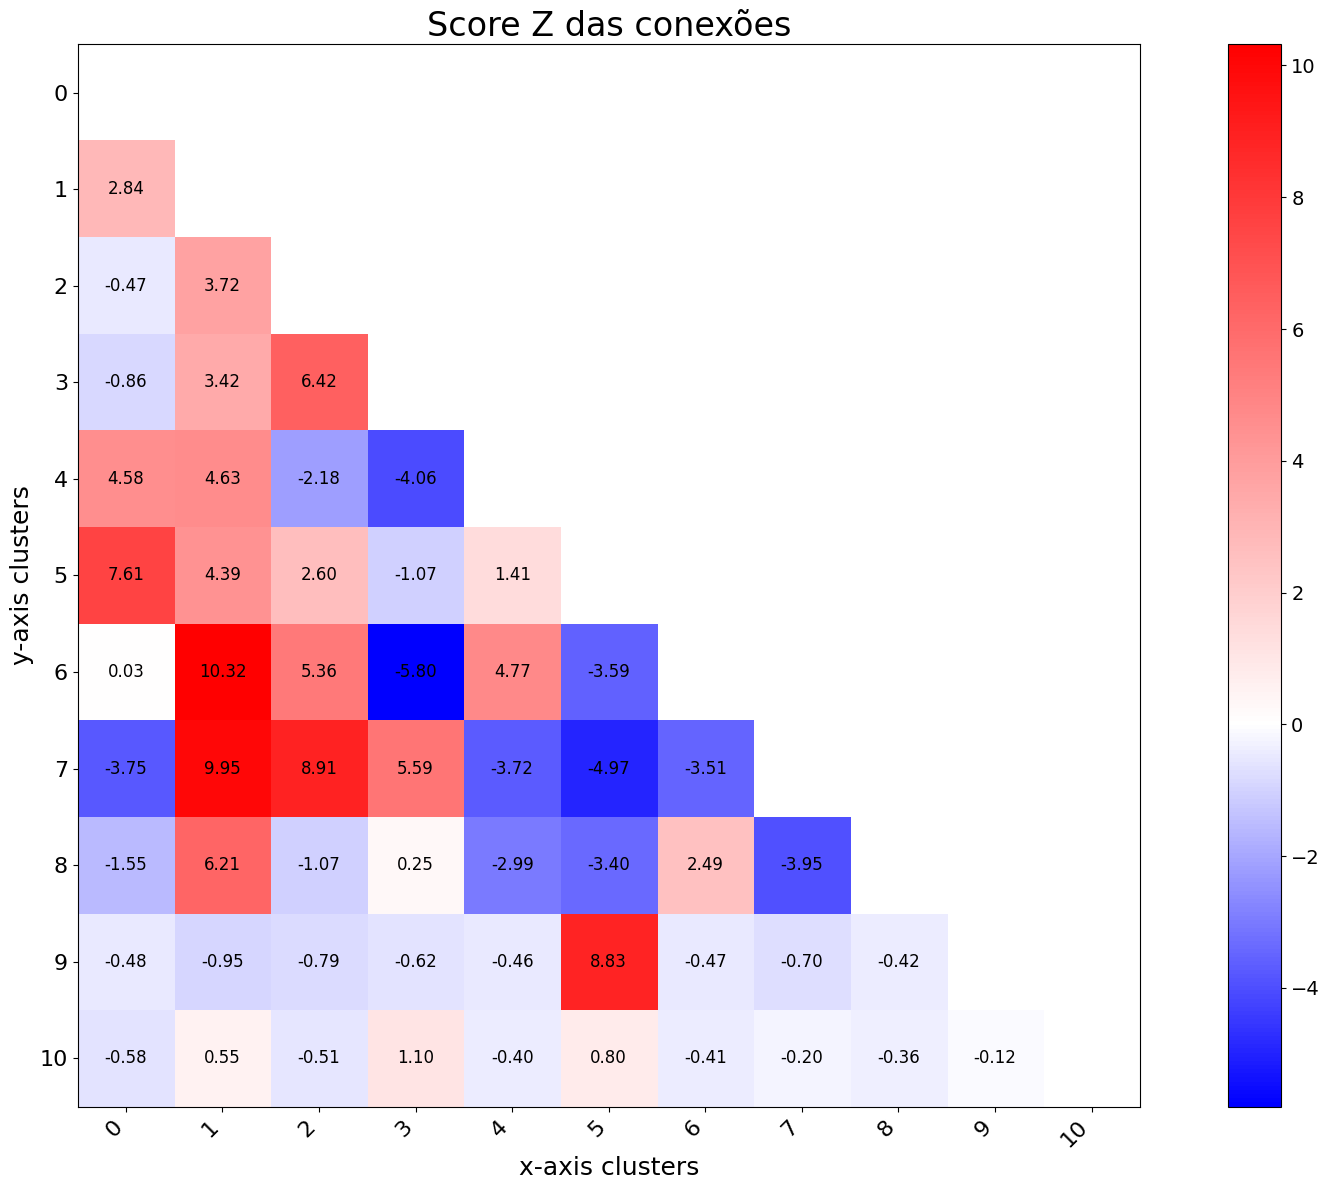

,0,1,2,3,4,5,6,7,8,9,10
0,0.000000,2.839670,-0.465604,-0.860406,4.584291,7.611051,0.025297,-3.749651,-1.548040,-0.484108,-0.584091
1,2.839670,0.000000,3.717307,3.421083,4.632056,4.385912,10.320199,9.950305,6.207237,-0.945526,0.545649
2,-0.465604,3.717307,0.000000,6.415640,-2.183399,2.604913,5.358979,8.913870,-1.069564,-0.794323,-0.510757
3,-0.860406,3.421083,6.415640,0.000000,-4.063179,-1.068307,-5.799708,5.591193,0.252216,-0.615868,1.096326
4,4.584291,4.632056,-2.183399,-4.063179,0.000000,1.406887,4.772075,-3.718314,-2.990895,-0.458342,-0.399184
5,7.611051,4.385912,2.604913,-1.068307,1.406887,0.000000,-3.586052,-4.967929,-3.399910,8.830214,0.801846
6,0.025297,10.320199,5.358979,-5.799708,4.772075,-3.586052,0.000000,-3.510938,2.488592,-0.473469,-0.412356
7,-3.749651,9.950305,8.913870,5.591193,-3.718314,-4.967929,-3.510938,0.000000,-3.954853,-0.701562,-0.201346
8,-1.548040,6.207237,-1.069564,0.252216,-2.990895,-3.399910,2.488592,-3.954853,0.000000,-0.417043,-0.363219
9,-0.484108,-0.945526,-0.794323,-0.615868,-0.458342,8.830214,-0.473469,-0.701562,-0.417043,0.000000,-0.116048


In [74]:
import spatools as st
st.pl.z_score_matrixplot(adata, show=True, title="Score Z das conexões")

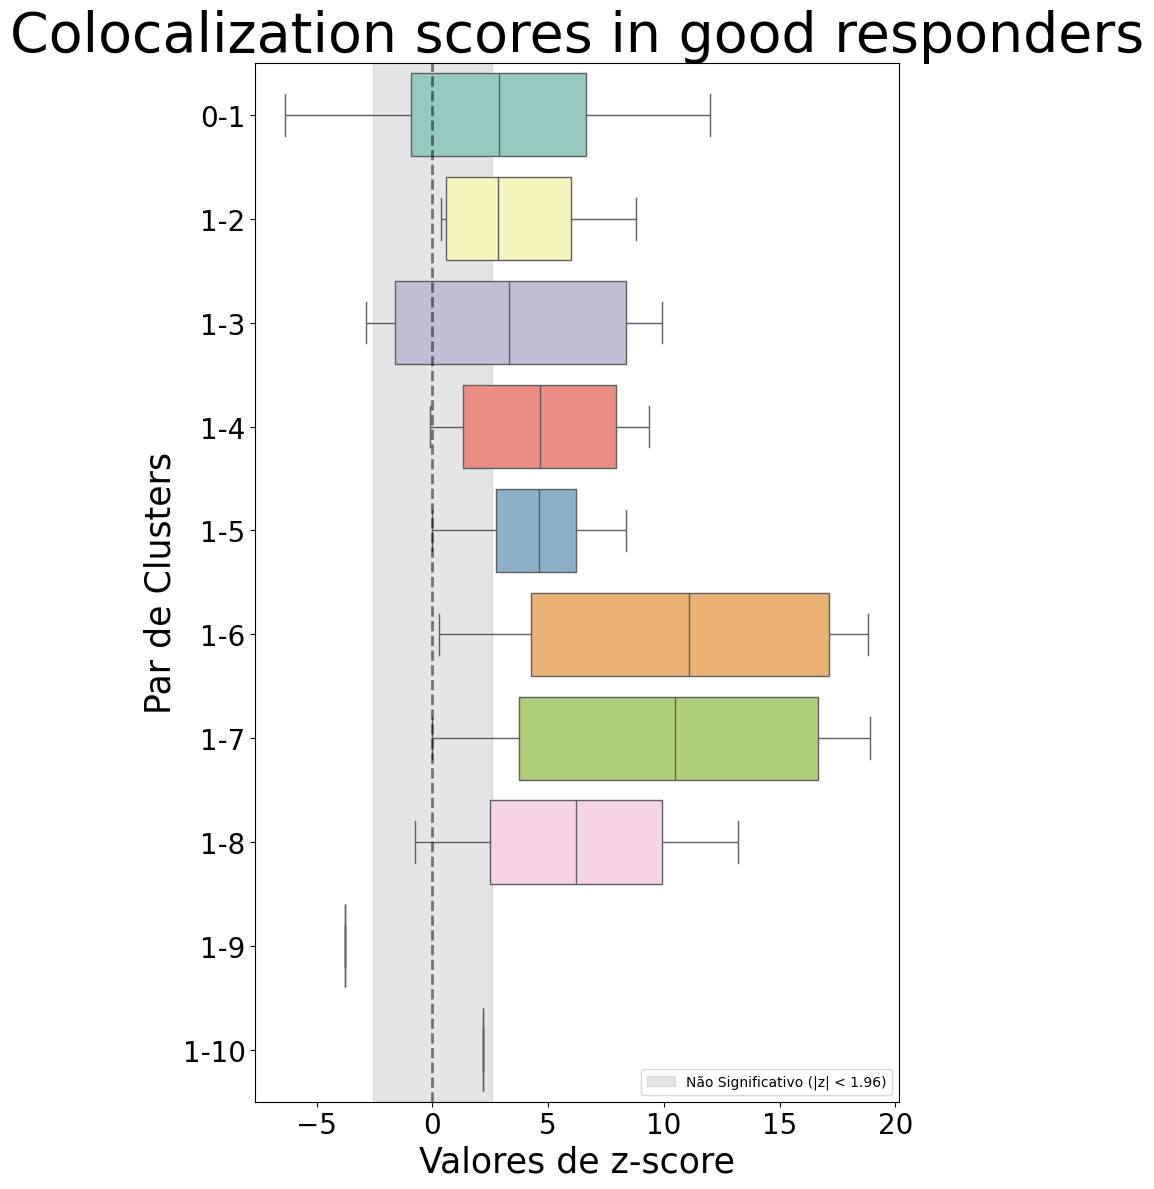

In [75]:
st.pl.boxplot_cluster_correlations(adata, cluster_col="leiden_0.5", 
                             show=True, 
                             title="Colocalization scores in good responders",
                             subset=True,
                             value=1,
                             figsize=(8, 12),
                             title_font=40,
                             label_font= 25,
                             ticks_font=20
                             )

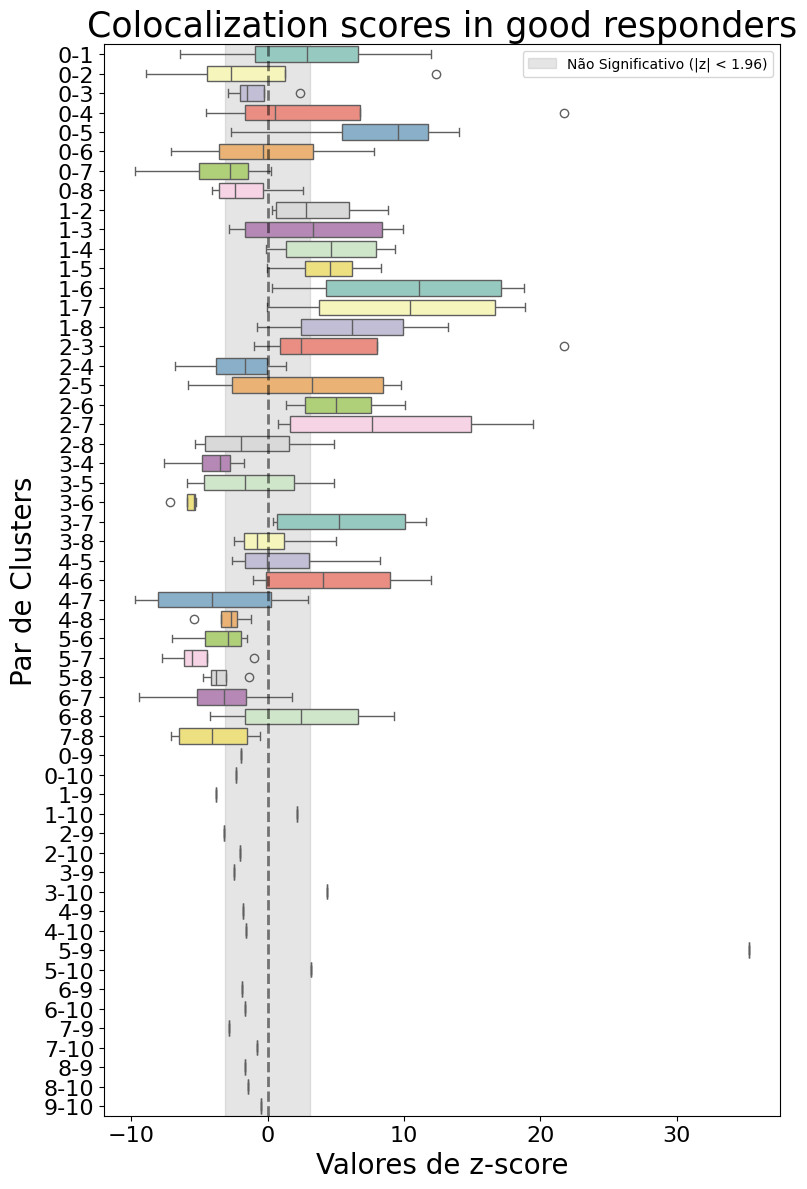

In [81]:
st.pl.boxplot_cluster_correlations(adata, cluster_col="leiden_0.5", 
                             title="Colocalization scores in good responders",
                             subset=False,
                             figsize=(8, 12),
                             title_font=25,
                             label_font= 20,
                             ticks_font=16,
                             show=True,
                             )

In [76]:
adata.uns["stats"]

,sample_key,Cluster Pair,Correlation,pval,FDR_pval,significant
0,FB_P1_S2,0-1,0.897503,3.694507e-01,4.652342e-01,False
1,FB_P1_S2,1-2,0.660067,5.092107e-01,5.970057e-01,False
2,FB_P1_S2,1-3,9.930587,3.064466e-23,1.488455e-22,True
3,FB_P1_S2,1-4,9.343514,9.318882e-21,3.960525e-20,True
4,FB_P1_S2,1-5,5.515869,3.470610e-08,7.375046e-08,True
5,FB_P1_S2,1-6,5.573169,2.501473e-08,5.670006e-08,True
6,FB_P1_S2,1-7,-0.017223,9.862586e-01,9.905046e-01,False
7,FB_P1_S2,1-8,-0.760478,4.469689e-01,5.427480e-01,False
8,FB_P26_S4,0-1,4.863389,1.153925e-06,2.064918e-06,True
9,FB_P26_S4,1-2,8.810200,1.249231e-18,4.247386e-18,True
